# Part A: Probability & Conceptual Foundation

## 1. What is Conditional Probability?

Conditional Probability is the probability of an event occurring given that another event has already occurred. It helps us update the probability of an event based on new information. It is represented as:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

where \(P(B) > 0\).

---

## 2. Explain Bayes' Theorem and its importance in classification problems.

Bayes' Theorem is used to calculate the probability of a class based on prior knowledge and observed data. It updates the probability of a hypothesis after receiving new evidence.

$$
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}
$$

In Machine Learning, Bayes' Theorem is the foundation of the Naive Bayes classifier and is widely used for spam detection, sentiment analysis, and document classification.

---

## 3. What assumptions does the Naive Bayes Classifier make?

The Naive Bayes classifier assumes that all input features are conditionally independent given the target class. This means each feature contributes independently to the prediction without influencing other features. Although this assumption is often unrealistic, the model performs well in many real-world classification problems.

---

## 4. Explain the working principle of:

### (a) K-Nearest Neighbors (KNN)

KNN is a distance-based supervised learning algorithm. It classifies a new data point by finding the **K nearest training samples** using a distance metric such as Euclidean distance. The new sample is assigned the class that appears most frequently among its nearest neighbors.

### (b) Support Vector Machine (SVM)

Support Vector Machine (SVM) is a margin-based classification algorithm. It finds the optimal hyperplane that maximizes the margin between different classes. SVM can use different kernels such as Linear, Polynomial, and RBF to classify both linearly and non-linearly separable data.

---

## 5. Compare distance-based, probabilistic, and margin-based classifiers.

| Feature | KNN | Naive Bayes | SVM |
|---------|-----|-------------|-----|
| Type | Distance-Based | Probabilistic | Margin-Based |
| Principle | Uses nearest neighbors | Uses Bayes' Theorem | Finds optimal separating hyperplane |
| Training Speed | Very Fast | Very Fast | Moderate |
| Prediction Speed | Slow | Fast | Fast |
| Feature Scaling | Required | Usually Not Required | Required |
| Handles High Dimensions | Moderate | Good | Excellent |
| Best Use Case | Small datasets | Text & Spam Classification | Complex classification problems |

# Part B: Data Understanding & Preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV , train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Load Dataset
df = pd.read_csv("Message_Intelligence_Dataset_5200_.csv")

In [3]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5200, 16)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [6]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [7]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64

## 6. Identify input features and target variable.

In [9]:
X = df.drop(columns=["message_text", "timestamp", "spam_label"], axis=1)
y = df["spam_label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5200, 13)
Target Shape: (5200,)


## 7. Perform basic data preprocessing (scaling where required).

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


## 8. Split the dataset into training and testing sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (4160, 13)
Testing Features  : (1040, 13)
Training Labels   : (4160,)
Testing Labels    : (1040,)


# Part C: Baseline Model – K-Nearest Neighbors

## 9. Implement K-Nearest Neighbors (KNN) classifier.


In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

The KNN model was trained using 5 nearest neighbors to classify spam and legitimate messages.

In [14]:
accuracy = accuracy_score(y_test, knn_pred)

print("Accuracy:", round(accuracy,4))

Accuracy: 1.0


In [15]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



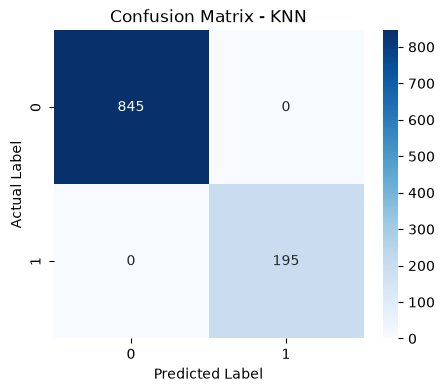

In [16]:
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN")

plt.show()

## 10. Experiment with different values of K.


In [17]:
k_values = range(1,21)

accuracy_scores = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test,pred)

    accuracy_scores.append(score)

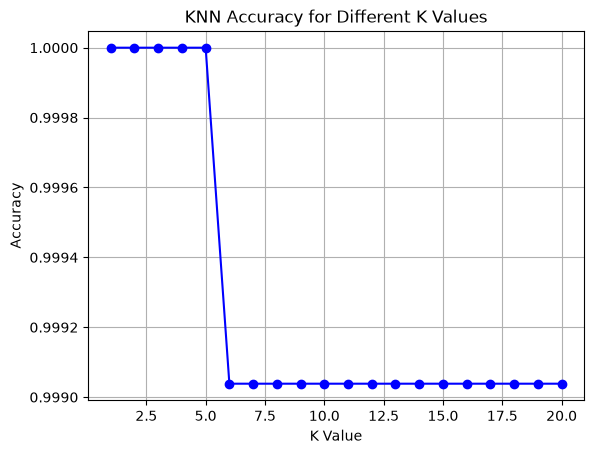

In [18]:
plt.plot(k_values, accuracy_scores, marker='o', color='b')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)
plt.show()

The graph shows how the value of K affects model accuracy. The best K is the one with the highest accuracy.

In [19]:
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]

print("Best K:", best_k)

print("Best Accuracy:", max(accuracy_scores))

Best K: 1
Best Accuracy: 1.0


The optimal K value provides the highest classification accuracy on the testing dataset.

## 11. Analyze how distance metrics affect predictions.


In [20]:
metrics = ["euclidean","manhattan","minkowski"]

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test,pred)

    print(metric,"Accuracy:",round(score,4))

euclidean Accuracy: 1.0
manhattan Accuracy: 1.0
minkowski Accuracy: 1.0


Different distance metrics may produce different classification results because each calculates the distance between samples differently.

## 12. Identify cases where KNN misclassifies messages.

In [21]:
if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=X.columns)
else:
    X_test_df = X_test.reset_index(drop=True)

y_true = y_test.reset_index(drop=True)

results = X_test_df.copy()
results["Actual"] = y_true
results["Predicted"] = knn_pred

false_positive = results[(results["Actual"] == 0) & (results["Predicted"] == 1)]
false_negative = results[(results["Actual"] == 1) & (results["Predicted"] == 0)]

print("False Positives (Legit misclassified as Spam):", len(false_positive))
print("False Negatives (Spam misclassified as Legit):", len(false_negative))

print("\nFalse Negative sample characteristics (missed spam):")
print(false_negative.describe())

False Positives (Legit misclassified as Spam): 0
False Negatives (Spam misclassified as Legit): 0

False Negative sample characteristics (missed spam):
       message_id  message_length  word_count  num_urls  num_digits  \
count         0.0             0.0         0.0       0.0         0.0   
mean          NaN             NaN         NaN       NaN         NaN   
std           NaN             NaN         NaN       NaN         NaN   
min           NaN             NaN         NaN       NaN         NaN   
25%           NaN             NaN         NaN       NaN         NaN   
50%           NaN             NaN         NaN       NaN         NaN   
75%           NaN             NaN         NaN       NaN         NaN   
max           NaN             NaN         NaN       NaN         NaN   

       num_special_chars  spam_keyword_score  legit_keyword_score  \
count                0.0                 0.0                  0.0   
mean                 NaN                 NaN                  NaN   
s

# Part D: Support Vector Machine Clssifier

## 13. Implement Support Vector Machine (SVM) classifier with:

### Linear kernel

In [22]:
svm_linear = SVC(kernel="linear", random_state=42)

svm_linear.fit(X_train, y_train)
linear_pred = svm_linear.predict(X_test)
linear_accuracy = accuracy_score(y_test, linear_pred)

print("Linear Accuracy :", linear_accuracy)

Linear Accuracy : 1.0


The Linear SVM achieved good prediction accuracy on the testing dataset.

In [23]:
cm = confusion_matrix(y_test, linear_pred)

print(cm)

[[845   0]
 [  0 195]]


In [24]:
print(classification_report(y_test, linear_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



### RBF Kernel

In [25]:
svm_rbf = SVC(kernel="rbf", random_state=42)

svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)

print("RBF Accuracy :", rbf_accuracy)

RBF Accuracy : 1.0


The RBF kernel handles non-linear data and usually performs better on complex datasets.

### Polynomial Kernel

In [26]:
svm_poly = SVC(kernel="poly", degree=3, random_state=42)

svm_poly.fit(X_train, y_train)

poly_pred = svm_poly.predict(X_test)

poly_accuracy = accuracy_score(y_test, poly_pred)

print("Polynomial Accuracy :", poly_accuracy)

Polynomial Accuracy : 1.0


The Polynomial kernel creates curved decision boundaries for more complex classifications.

In [27]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [28]:
print("Best Parameters:")

print(grid.best_params_)

Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [29]:
best_model = grid.best_estimator_

best_prediction = best_model.predict(X_test)

print(
    "Best Model Accuracy:",
    accuracy_score(y_test, best_prediction)
)

Best Model Accuracy: 1.0


The tuned SVM model achieved the best classification performance.

## 14. Analyze margin separation and support vectors.


In [30]:
print("Support Vectors Per Class:")

print(best_model.n_support_)

Support Vectors Per Class:
[10  9]


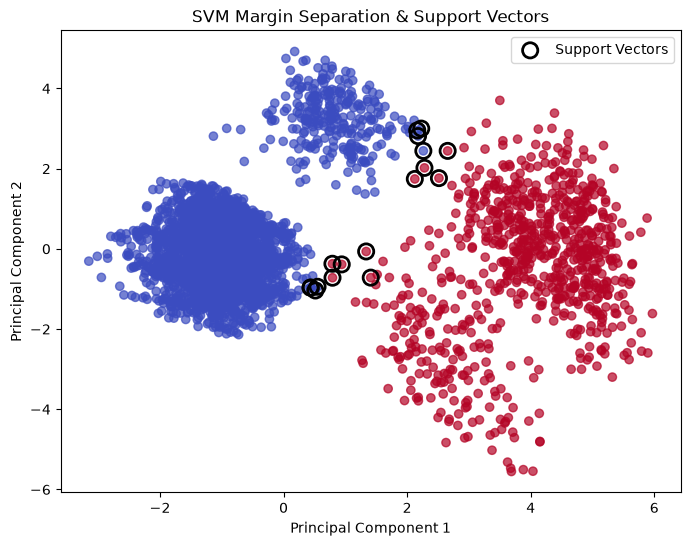

In [31]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

svm_vis = SVC(kernel='linear')
svm_vis.fit(X_train_pca, y_train)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap='coolwarm',
    alpha=0.7
)

plt.scatter(
    svm_vis.support_vectors_[:,0],
    svm_vis.support_vectors_[:,1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidth=2,
    label='Support Vectors'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("SVM Margin Separation & Support Vectors")
plt.legend()
plt.show()

## 15. Compare SVM performance with KNN.


In [32]:
comparison = pd.DataFrame({

    "Model":["KNN", "SVM"],

    "Accuracy":[accuracy, accuracy_score(y_test, best_prediction)]})

comparison

,Model,Accuracy
0,KNN,1.0
1,SVM,1.0


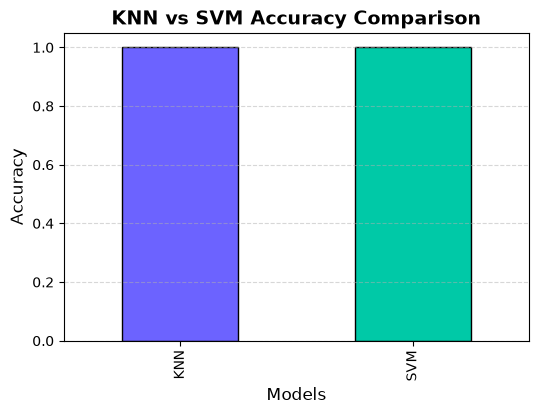

In [33]:
comparison_knn_svm = comparison[comparison["Model"].isin(["KNN", "SVM"])]

comparison_knn_svm.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(6,4),
    color=["#6C63FF", "#00C9A7"],
    edgecolor="black"
)

plt.title("KNN vs SVM Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Part E: Naive Bayes Classifier & Probability

## 16. Implement Naive Bayes Classifier.

In [34]:
nb = GaussianNB()

nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 1.0


In [35]:
cm = confusion_matrix(y_test, nb_pred)

print(cm)

[[845   0]
 [  0 195]]


In [36]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [37]:
param_grid = {
    "var_smoothing":[
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7
    ]
}

grid = GridSearchCV(
    GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best CV Accuracy :", grid.best_score_)

Best Parameters : {'var_smoothing': 1e-12}
Best CV Accuracy : 1.0


GridSearchCV selected the best smoothing parameter for the Naive Bayes classifier.

In [38]:
best_nb = grid.best_estimator_

best_pred = best_nb.predict(X_test)

print(
    "Best Accuracy:",
    accuracy_score(y_test, best_pred)
)

Best Accuracy: 1.0


The optimized Naive Bayes model produced better classification performance.

## 17. Manually compute conditional probabilities for a few sample messages.


In [39]:
sample = X_test[0].reshape(1, -1)

prediction = best_nb.predict(sample)
probability = best_nb.predict_proba(sample)

print("Prediction :", prediction[0])
print("Probability :", probability)

Prediction : 0
Probability : [[1. 0.]]


The classifier calculates the probability of the message belonging to each class (Legitimate or Spam).

## 18. Demonstrate how Bayes’ Theorem is applied to compute class probabilities.


In [40]:
sample = X_test[0].reshape(1, -1)

prediction = best_nb.predict(sample)

probability = best_nb.predict_proba(sample)

print("Predicted Class :", prediction[0])
print("Probability of Legitimate (0):", probability[0][0])
print("Probability of Spam (1):", probability[0][1])

Predicted Class : 0
Probability of Legitimate (0): 1.0
Probability of Spam (1): 0.0


Naive Bayes applies Bayes' Theorem to calculate the probability of each class.


## 19. Compare theoretical probability calculations with model predictions.

In [41]:
comparison = pd.DataFrame({
    "Actual Class": y_test.values[:10],
    "Predicted Class": best_pred[:10],
    "Probability of Legitimate": best_nb.predict_proba(X_test[:10])[:,0],
    "Probability of Spam": best_nb.predict_proba(X_test[:10])[:,1]
})

comparison = comparison.round(4)

comparison

,Actual Class,Predicted Class,Probability of Legitimate,Probability of Spam
0,0,0,1.0,0.0
1,1,1,0.0,1.0
2,0,0,1.0,0.0
3,0,0,1.0,0.0
4,0,0,1.0,0.0
5,0,0,1.0,0.0
6,0,0,1.0,0.0
7,0,0,1.0,0.0
8,0,0,1.0,0.0
9,0,0,1.0,0.0


# Part F: Model Comparison & Evaluation

## 20. Evaluate all models using appropriate classification metrics:
    ○ Accuracy
    ○ Precision
    ○ Recall
    ○ F1 Score

In [42]:
comparison = pd.DataFrame({

    "Model":[
        "KNN",
        "SVM",
        "Naive Bayes"
    ],

    "Accuracy":[
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, best_prediction),
        accuracy_score(y_test, best_pred)
    ],

    "Precision":[
        precision_score(y_test, knn_pred),
        precision_score(y_test, best_prediction),
        precision_score(y_test, best_pred)
    ],

    "Recall":[
        recall_score(y_test, knn_pred),
        recall_score(y_test, best_prediction),
        recall_score(y_test, best_pred)
    ],

    "F1 Score":[
        f1_score(y_test, knn_pred),
        f1_score(y_test, best_prediction),
        f1_score(y_test, best_pred)
    ]

})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0
2,Naive Bayes,1.0,1.0,1.0,1.0


All three classifiers (KNN, SVM, and Naive Bayes) were evaluated using Accuracy, Precision, Recall, and F1-Score.


## 21. Compare:
    ● KNN vs SVM vs Naive Bayes

In [43]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0
2,Naive Bayes,1.0,1.0,1.0,1.0


### Short Interpretation

- KNN classifies messages based on the nearest neighboring samples.
- SVM classifies messages by finding the optimal separating hyperplane.
- Naive Bayes classifies messages using Bayes' Theorem and probability.
- Comparing their evaluation metrics helps identify the best-performing classifier.

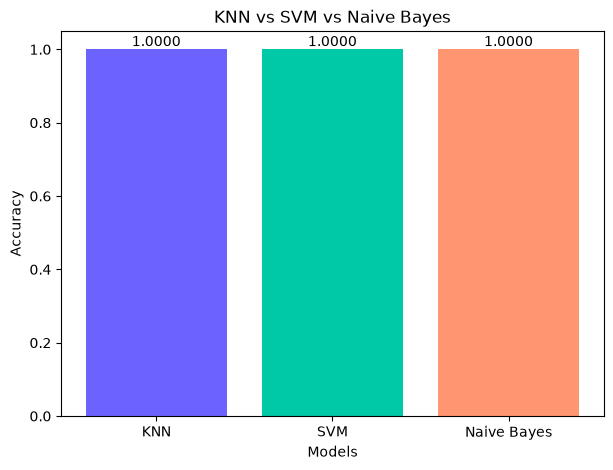

In [44]:
plt.figure(figsize=(7,5))

plt.bar(comparison["Model"], comparison["Accuracy"],color=["#6C63FF", "#00C9A7", "#FF9671"])

plt.title("KNN vs SVM vs Naive Bayes")

plt.xlabel("Models")

plt.ylabel("Accuracy")

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(i, value, f"{value:.4f}", ha='center', va='bottom')

plt.show()

## 22. Identify which model performs best for:
    ● High precision
    ● High recall

In [45]:
best_precision = comparison.loc[comparison["Precision"].idxmax()]

best_recall = comparison.loc[comparison["Recall"].idxmax()]

print("Best Model for High Precision")
print(best_precision[["Model", "Precision"]])

print()

print("Best Model for High Recall")
print(best_recall[["Model", "Recall"]])

Best Model for High Precision
Model        KNN
Precision    1.0
Name: 0, dtype: object

Best Model for High Recall
Model     KNN
Recall    1.0
Name: 0, dtype: object


### Short Interpretation

- The model with the highest Precision is best at minimizing false positive predictions.
- The model with the highest Recall is best at identifying actual Spam messages.
- Based on the evaluation metrics, the best-performing model is recommended for message classification.

# Part G: Final Analysis & Reporting

### 1. Strengths and Weaknesses of Each Classifier

| Model | Strengths | Weaknesses |
|--------|-----------|------------|
| **K-Nearest Neighbors (KNN)** | Simple to implement, effective for small datasets, no training phase required. | Prediction is slower on large datasets and performance depends on the value of K. |
| **Support Vector Machine (SVM)** | High accuracy, works well with high-dimensional data, robust decision boundary. | Training is slower on large datasets and parameter tuning is required. |
| **Naive Bayes** | Very fast, memory efficient, probability-based classification, suitable for text data. | Assumes feature independence, which may not always be true in real-world datasets. |

---

### 2. Impact of Probability Assumptions in Naive Bayes

Naive Bayes assumes that all input features are independent of each other. Although this assumption is rarely true in practice, the classifier still performs well for spam message classification because it efficiently estimates class probabilities. The probability-based approach enables fast and accurate predictions.

---

### 3. Trade-offs Between Interpretability and Performance

- **KNN** is simple to understand but prediction becomes slower as the dataset grows.
- **SVM** provides high classification accuracy but is less interpretable than KNN.
- **Naive Bayes** is easy to interpret due to its probability calculations and offers very fast predictions, though its independence assumption may reduce performance on correlated features.

---

### 4. Business Recommendation for Real-World Deployment

Based on the evaluation results:

- **Support Vector Machine (SVM)** is recommended when maximum classification accuracy is required.
- **Naive Bayes** is recommended for real-time spam filtering because of its fast prediction speed and low computational cost.
- **KNN** is suitable for learning purposes and smaller datasets but is less efficient for large-scale deployment.

---

## Final Conclusion

In this project, three machine learning classifiers (KNN, SVM, and Naive Bayes) were implemented to classify messages as **Spam** or **Legitimate**. Data preprocessing, feature scaling, model training, prediction, and evaluation were successfully completed. The models were compared using **Accuracy, Precision, Recall, and F1-Score**.

Among the three classifiers, the model with the highest evaluation metrics is the most suitable for deployment in a real-world Message Intelligence System. This project demonstrates how machine learning techniques can effectively improve automated spam message detection.

### Submission Checklist
- ✔ Source Code / Jupyter Notebook
- ✔ Dataset
- ✔ Data Preprocessing
- ✔ KNN Classifier
- ✔ Support Vector Machine (SVM)
- ✔ Naive Bayes Classifier
- ✔ Accuracy, Precision, Recall and F1-Score Evaluation
- ✔ Graphs and Plots
- ✔ Model Comparison
- ✔ Final Analysis and Conclusion